# Review 1 — Regression Track
## Dataset: Ames Housing (Kaggle: House Prices — Advanced Regression Techniques)

**Target:** `SalePrice` (continuous)
**Size:** 1460 rows × 81 columns

Only the labelled training file is used. An internal stratified 80/20 split provides
the test set, since the Kaggle competition test file has no SalePrice labels.

## Section A — Dataset & EDA

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/Ameshousing.csv')
print("Rows:", df.shape[0], " Columns:", df.shape[1])

Rows: 1460  Columns: 81


### A1 — Dataset Loading & Audit

Reporting shape, data types, missing-value counts, and the target distribution.

In [27]:
print("----- SHAPE -----")
print(df.shape)

print("\n----- DATA TYPES -----")
print(df.dtypes.value_counts())

print("\n----- MISSING VALUES -----")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print("Columns with missing values:", len(missing_table))
print(missing_table)

print("\n----- TARGET DISTRIBUTION -----")
print(df['SalePrice'].describe())
print("\nSkewness:", round(df['SalePrice'].skew(), 3))
print("Duplicate rows:", df.duplicated().sum())

----- SHAPE -----
(1460, 81)

----- DATA TYPES -----
object     43
int64      35
float64     3
Name: count, dtype: int64

----- MISSING VALUES -----
Columns with missing values: 19
              Missing  Percent
PoolQC           1453    99.52
MiscFeature      1406    96.30
Alley            1369    93.77
Fence            1179    80.75
MasVnrType        872    59.73
FireplaceQu       690    47.26
LotFrontage       259    17.74
GarageType         81     5.55
GarageYrBlt        81     5.55
GarageFinish       81     5.55
GarageQual         81     5.55
GarageCond         81     5.55
BsmtExposure       38     2.60
BsmtFinType2       38     2.60
BsmtQual           37     2.53
BsmtCond           37     2.53
BsmtFinType1       37     2.53
MasVnrArea          8     0.55
Electrical          1     0.07

----- TARGET DISTRIBUTION -----
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max  

### A2 — EDA Visualisations

Distribution plots for all numeric features, correlation heatmap, target distribution,
and two feature–target scatter plots.

The heatmap is restricted to the 12 features most correlated with SalePrice. The full
38×38 numeric matrix is unreadable when annotated.

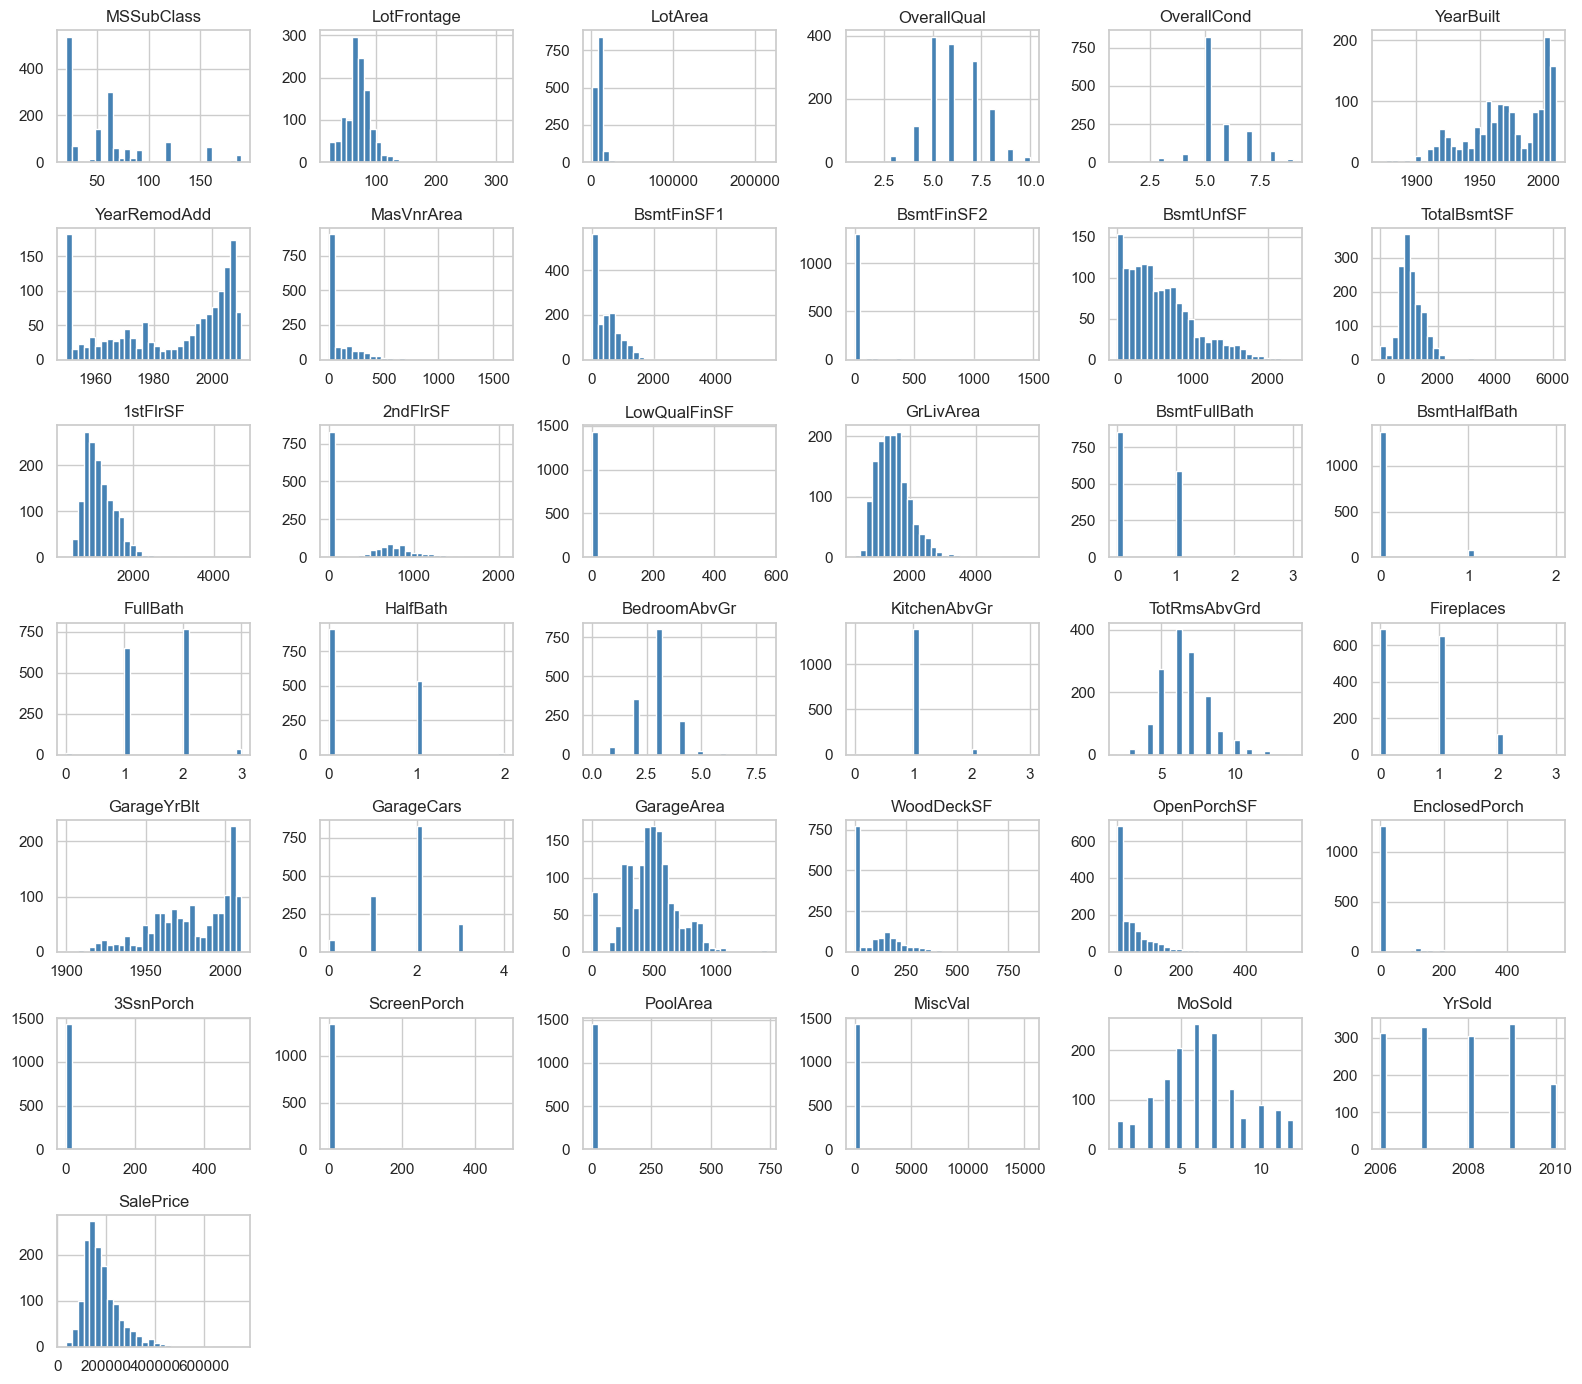

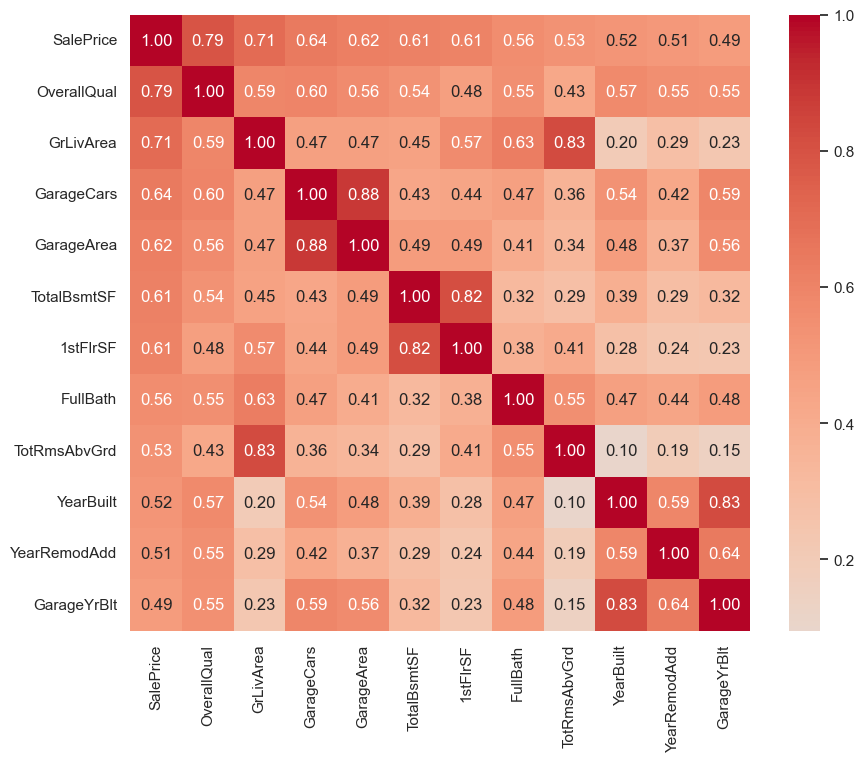

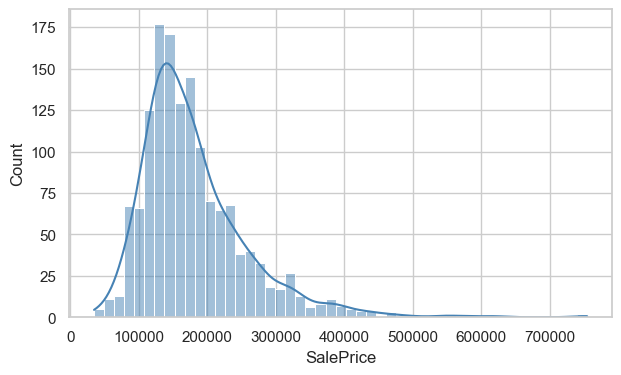

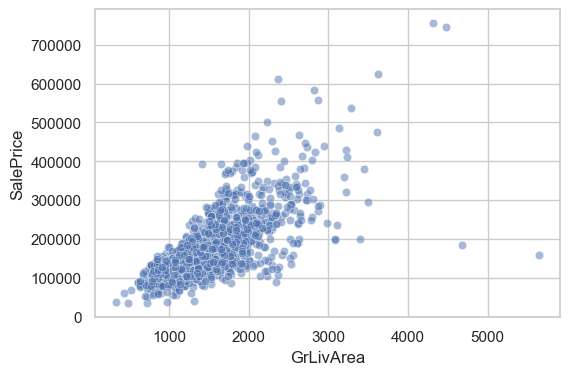

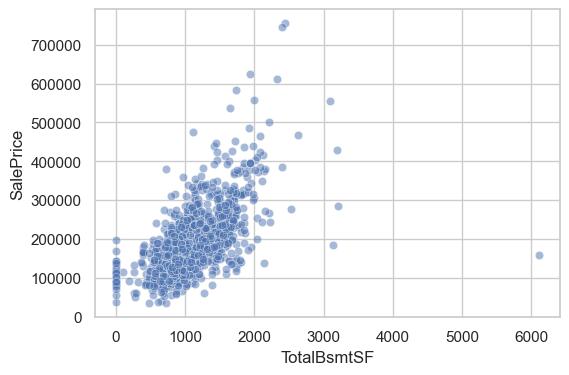

In [28]:
numeric_df = df.select_dtypes(include=np.number).drop(columns=['Id'])
numeric_df.hist(figsize=(16,14), bins=30, color='steelblue', edgecolor='white')
plt.tight_layout()
plt.show()

corr = numeric_df.corr()
top_features = corr['SalePrice'].abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(10,8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], alpha=0.5)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['TotalBsmtSF'], y=df['SalePrice'], alpha=0.5)
plt.show()


### A3 — Insight Commentary

**Data audit.** 1460 rows, 81 columns — 43 object, 35 int64, 3 float64. No duplicate rows.
19 columns contain missing values, but the missingness is highly uneven: PoolQC (99.52%),
MiscFeature (96.30%), Alley (93.77%) and Fence (80.75%) are almost entirely empty, while the
five Garage columns are each missing exactly 81 values (5.55%). Checking the raw data confirms
those are the *same* 81 rows missing all five garage columns at once, so these are structural
absences — houses with no garage — rather than random missing data. The same reasoning applies
to PoolQC: NaN means no pool, not unknown. Median-filling these would invent features that
don't exist.

**Feature distributions.** Several area columns (MasVnrArea, 2ndFlrSF, PoolArea, MiscVal) spike
sharply at zero, consistent with the same absence-not-missing interpretation. LotArea and
several porch measures are heavily right-skewed. YearBuilt is left-skewed, indicating most of
the housing stock is relatively recent.

**Correlation heatmap.** OverallQual (r = 0.79) and GrLivArea (r = 0.71) are the strongest
predictors of SalePrice, followed by GarageCars (0.64) and GarageArea (0.62). Three pairs are
strongly collinear with each other: GarageCars–GarageArea (0.88), GrLivArea–TotRmsAbvGrd (0.83)
and TotalBsmtSF–1stFlrSF (0.82). Each pair effectively measures the same thing twice, which
inflates coefficient variance in ordinary least squares and motivates testing regularised
models (Ridge, Lasso, ElasticNet) alongside plain Linear Regression.

**Target distribution.** SalePrice is right-skewed (skewness = 1.883). The middle 50% of sales
fall between $129,975 and $214,000, but the range runs from $34,900 to $755,000. The mean
($180,921) sits well above the median ($163,000), which is the numerical signature of that
right tail. Linear models assume approximately normal residuals, so a log transform is applied
to the target before modelling.

**GrLivArea vs SalePrice.** Strong positive linear relationship. Not every large house is an
outlier — several homes above 4000 sq ft sold near the top of the price range and sit on the
trend line. The problem cases are two houses above 4000 sq ft that sold below $300,000, far
beneath the trend. These are partial sales and are removed in B1; the expensive large homes
are kept.

**TotalBsmtSF vs SalePrice.** Positive relationship, with a distinct vertical cluster at x = 0
representing houses with no basement. One house with an unusually large basement sold far below
the trend — the same partial-sale record visible in the plot above.

## Section B — Preprocessing & Feature Engineering

### B1 — Data Cleaning

**Justification.** Missing values fall into two groups and must be treated differently.

*Structurally absent.* The five Garage columns are each missing exactly 81 values — the same
81 houses, which simply have no garage. Likewise NaN in PoolQC means no pool, not unknown.
Median-filling these would invent features that do not exist, so they are filled with
'None' (categorical) or 0 (numeric).

*Genuinely unknown.* LotFrontage is a real measurement that was not recorded. It is filled
with the neighbourhood median, since lot frontage clusters strongly by locality.

**Outliers.** Two houses larger than 4000 sq ft sold for under $300k — far below what their
size predicts. These are partial sales rather than ordinary market transactions, so they
distort the price–area relationship and are removed. Large houses that sold at high prices
are retained, since they follow the trend and are legitimate observations.

**Result:** 0 duplicate rows, 2 outliers removed, 0 remaining missing values.

In [29]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

NONE_MEANS_ABSENT = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu','GarageType',
                     'GarageFinish','GarageQual','GarageCond','BsmtQual','BsmtCond',
                     'BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType','Electrical']
ZERO_MEANS_ABSENT = ['GarageYrBlt','MasVnrArea']

for c in NONE_MEANS_ABSENT:
    df[c] = df[c].fillna('None')
for c in ZERO_MEANS_ABSENT:
    df[c] = df[c].fillna(0)

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda s: s.fillna(s.median()))
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

n0 = len(df)
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))].reset_index(drop=True)
print("Outliers removed:", n0 - len(df))
print("Remaining missing values:", df.isnull().sum().sum())

Duplicates before: 0
Outliers removed: 2
Remaining missing values: 0


### B3 — Feature Engineering

**Justification.** Buyers price total usable space, but no single column captures it — basement,
first floor and second floor are stored separately. TotalSF sums them.

The result confirms the reasoning. TotalSF correlates with SalePrice at **0.833**, stronger than
either of its main components (GrLivArea 0.735, TotalBsmtSF 0.651) and stronger than OverallQual
(0.79), the best original feature in the dataset.

HouseAge (YrSold − YearBuilt) is more meaningful than raw YearBuilt, since what affects price is
the age of the house at sale rather than the calendar year it was built. Its correlation is
**−0.524** — negative as expected, because older houses sell for less.

TotalBath (0.636) combines the four separate bathroom counts into one weighted measure, with
half-baths weighted at 0.5.

In [30]:
df['TotalSF']   = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge']  = df['YrSold'] - df['YearBuilt']
df['TotalBath'] = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']

for c in ['TotalSF','HouseAge','TotalBath']:
    print(c, "corr with SalePrice =", round(df[c].corr(df['SalePrice']), 3))
print("TotalBsmtSF corr =", round(df['TotalBsmtSF'].corr(df['SalePrice']), 3))
print("GrLivArea   corr =", round(df['GrLivArea'].corr(df['SalePrice']), 3))

TotalSF corr with SalePrice = 0.833
HouseAge corr with SalePrice = -0.524
TotalBath corr with SalePrice = 0.636
TotalBsmtSF corr = 0.651
GrLivArea   corr = 0.735


### B2 — Encoding, Scaling & Splitting

The split happens before any fitting, and the scaler sits inside a ColumnTransformer, so it is
fitted on training data only. This makes leakage structurally impossible, including later during
cross-validation.

Numeric features are standardised, which Ridge, Lasso, ElasticNet, SVR and KNN all require since
they are penalty- or distance-based. Categorical features are one-hot encoded with
handle_unknown='ignore', so a category appearing only in the test split cannot raise an error.

The rubric asks for a stratified split. Stratification normally applies to classification, so the
continuous target is binned into price quintiles and stratified on those, preserving the price
distribution across train and test.

**Result:** 1166 training rows, 292 test rows, 82 input columns expanding to ___ after encoding.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.drop(columns=['SalePrice', 'Id'])
y = np.log1p(df['SalePrice'])

strata = pd.qcut(df['SalePrice'], q=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=strata)
print("Train:", X_train.shape, " Test:", X_test.shape)

num_f = X.select_dtypes(include=np.number).columns.tolist()
cat_f = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_f),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_f)
])

preprocessor.fit(X_train)
print("Features after encoding:", preprocessor.transform(X_train).shape[1])

Train: (1166, 82)  Test: (292, 82)
Features after encoding: 302


In [32]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [33]:
POLY_COLS = ['OverallQual','GrLivArea','TotalSF','TotalBsmtSF','GarageCars','HouseAge']
poly_pre = ColumnTransformer([
    ('poly', Pipeline([('sc', StandardScaler()),
                       ('pf', PolynomialFeatures(degree=2, include_bias=False))]), POLY_COLS)
])

models = {
    'Linear Regression':     (preprocessor, LinearRegression()),
    'Ridge Regression':      (preprocessor, Ridge(alpha=10)),
    'Lasso Regression':      (preprocessor, Lasso(alpha=0.001)),
    'ElasticNet':            (preprocessor, ElasticNet(alpha=0.001, l1_ratio=0.5)),
    'Polynomial Regression': (poly_pre,     LinearRegression()),
    'Decision Tree':         (preprocessor, DecisionTreeRegressor(max_depth=8, random_state=42)),
    'Random Forest':         (preprocessor, RandomForestRegressor(n_estimators=200, random_state=42)),
    'Gradient Boosting':     (preprocessor, GradientBoostingRegressor(random_state=42)),
    'SVR':                   (preprocessor, SVR(C=10, kernel='rbf')),
    'KNN Regressor':         (preprocessor, KNeighborsRegressor(n_neighbors=5)),
}

results = []
fitted = {}

for name, (prep, model) in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)

    pred   = np.expm1(pipe.predict(X_test))
    actual = np.expm1(y_test)

    results.append({
        'Model': name,
        'R2':   round(r2_score(actual, pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(actual, pred))),
        'MAE':  round(mean_absolute_error(actual, pred))
    })
    fitted[name] = pipe
    print(name, "done")

Linear Regression done
Ridge Regression done
Lasso Regression done
ElasticNet done
Polynomial Regression done
Decision Tree done
Random Forest done
Gradient Boosting done
SVR done
KNN Regressor done


In [34]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
print(results_df.to_string())

                    Model      R2   RMSE    MAE
1        Lasso Regression  0.9385  16622  11812
2              ElasticNet  0.9366  16874  12158
3        Ridge Regression  0.9328  17380  12592
4       Gradient Boosting  0.9188  19102  13528
5       Linear Regression  0.9111  19985  14395
6           Random Forest  0.8941  21816  14913
7                     SVR  0.8896  22272  14795
8   Polynomial Regression  0.8687  24287  17392
9           KNN Regressor  0.8587  25194  17853
10          Decision Tree  0.7763  31706  21041
